In [ ]:
import numpy as np
import pandas as pd

import statsmodels.api as sm

import seaborn as sns
import matplotlib.pylab as plt

from sklearn.metrics import r2_score as r2
from sklearn.metrics import mean_absolute_percentage_error as mape

import warnings
warnings.filterwarnings('ignore')

Есть данные о продажах, остатках, закупках по клиентам. Задача - прогноз продаж с учетом всех данных и сезонности по месяцам. Будем использовать линейную регрессию

In [ ]:
df = pd.read_excel('Case_Analyst_Решение.xlsx', sheet_name  = 'data').fillna(0)
df.head()

,Период,Клиент,Продажи,Остатки,Закупки
0,2020-01-01,Григорий,1.680468e+08,2.994128e+08,2.095030e+08
1,2020-02-01,Григорий,2.036499e+08,3.381993e+08,1.539659e+08
2,2020-03-01,Григорий,2.566368e+08,3.322793e+08,3.491804e+08
3,2020-04-01,Григорий,2.317790e+08,4.224878e+08,2.521181e+08
4,2020-05-01,Григорий,1.952722e+08,3.031453e+08,1.931633e+08


Считаю корреляцию между числовыми признаками по всем периодам, где есть исторические данныею Наибольша язависимсоть между закупками и остатками

In [ ]:
df[(df['Период'] < '2021-10')].corr()

,Продажи,Остатки,Закупки
Продажи,1.000000,-0.119264,0.112202
Остатки,-0.119264,1.000000,0.548046
Закупки,0.112202,0.548046,1.000000


Интересно, для разных клиентов зависимость между числовыми признаками разная? считаю корреляцию внутри групп - вижу что да, зависимость разная

In [ ]:
df[(df['Период'] < '2021-10')].groupby('Клиент').corr()

Продажи   Остатки   Закупки
Клиент                                         
Григорий  Продажи  1.000000  0.434445  0.689778
          Остатки  0.434445  1.000000  0.065826
          Закупки  0.689778  0.065826  1.000000
Другие    Продажи  1.000000  0.333582  0.147801
          Остатки  0.333582  1.000000 -0.336744
          Закупки  0.147801 -0.336744  1.000000
Екатерина Продажи  1.000000  0.038955  0.687662
          Остатки  0.038955  1.000000 -0.065527
          Закупки  0.687662 -0.065527  1.000000
Павел     Продажи  1.000000  0.009836  0.663929
          Остатки  0.009836  1.000000 -0.117113
          Закупки  0.663929 -0.117113  1.000000
Петр      Продажи  1.000000 -0.082693  0.538306
          Остатки -0.082693  1.000000 -0.535282
          Закупки  0.538306 -0.535282  1.000000
Федор     Продажи  1.000000  0.070568  0.414336
          Остатки  0.070568  1.000000 -0.261453
          Закупки  0.414336 -0.261453  1.000000

Данные все есть (нет пустых ячеек), но очистка нужна для оптимальной работы модели, пишу функцию, которая заменит значения выходящие за межквартильный размех на верхнюю или нижнюю границу межквартильного диапазона

In [ ]:
# Эта функция меняет значения, выходящие за пределы интерквартильного диапазона.
def remove_outliers(df, column):
    Q1 = np.percentile(df[column], 25)
    Q3 = np.percentile(df[column], 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    #меняем выбросы на верхнюю и нижнюю границу нормы
    df.loc[(df[column] < lower_bound), column] = lower_bound
    df.loc[(df[column] > upper_bound), column] = upper_bound

    return df

In [ ]:
#функция считает ошибки прогноза в долях от факта
def mist(df, fact, pred):
    df = df.assign(delta = lambda x: abs(x[fact] - x[pred]),
                                     pct = lambda x: x.delta / x[fact] )
    return(df)

Группирую данные по клиентам, чтобы для каждого расчитать линейную регрессию

In [ ]:
grouped_df = df.groupby(['Клиент'])

Циклом обхожу клиентов и для каждого чищу данные, строю ргерессию по имеющимся числовым признакам + сезонность. Сезонная компонента представлена фиктивными переменными месяца, регрессия будет искать коэффициент перед фиктивной переменной - это и будет искомая сезонная добавка к тренду. Метрики модели  R2 и MAPE, их вывожу в конце каждого цикла вместе с графиком факт_прогноз для визуализации качества модели

Клиент  Григорий
R2 на трейне 0.8967257228156712
MAPE на трейне 0.06831840628911745


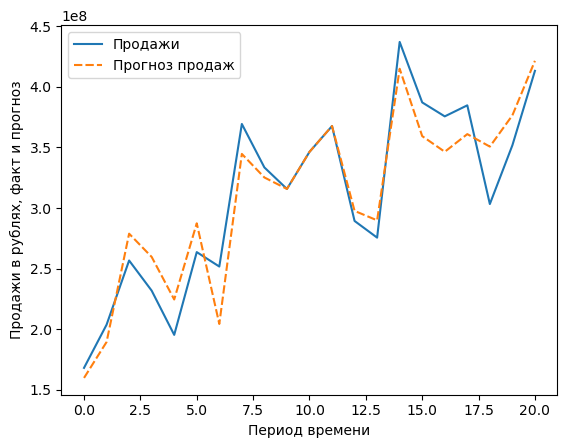

Клиент  Другие
R2 на трейне 0.797940258846628
MAPE на трейне 0.10621537327168945


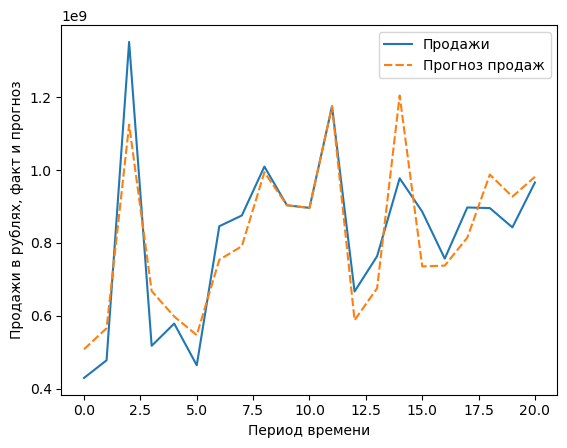

Клиент  Екатерина
R2 на трейне 0.8539926871983682
MAPE на трейне 0.07727835190524994


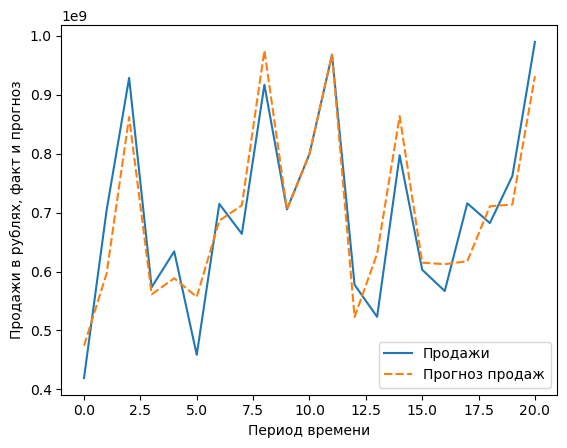

Клиент  Павел
R2 на трейне 0.8293340527034017
MAPE на трейне 0.10957001394392438


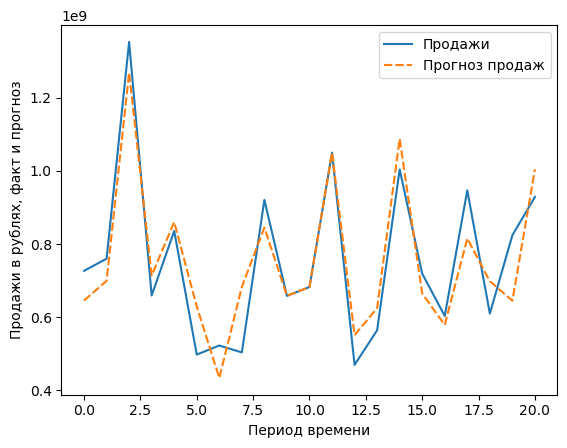

Клиент  Петр
R2 на трейне 0.8830120359780352
MAPE на трейне 0.06708155148727443


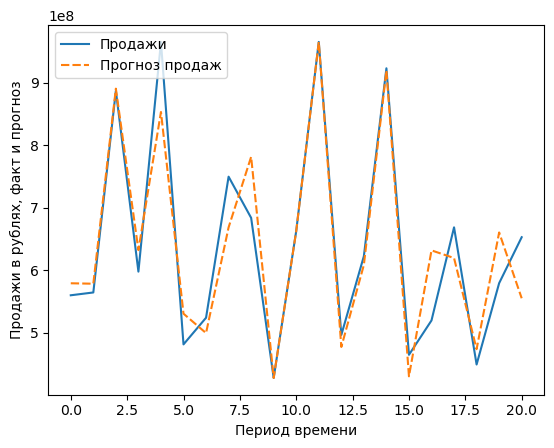

Клиент  Федор
R2 на трейне 0.6486976849109176
MAPE на трейне 0.122682946106492


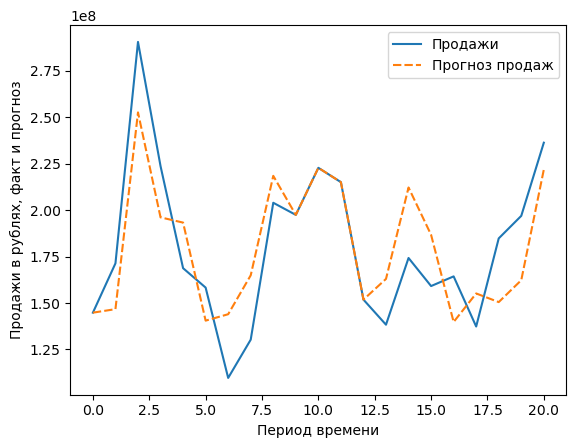

In [ ]:
#Пустой фрейм для записи результатов
df_pred = pd.DataFrame()

#Цикл по группам - клиентам
for group_name, group_data in grouped_df:

    y = group_data.reset_index()

    #очистка данных о продажах
    y = remove_outliers(y,'Закупки').reset_index(drop = True)
    y = remove_outliers(y,'Продажи').reset_index(drop = True)
    y = remove_outliers(y,'Остатки').reset_index(drop = True)

    #тренд и номер месяца для регрессии
    y = y.assign(trend = y.index,
                 month = y['Период'].dt.month.astype('object'))

    #фиктивные переменные - месяцы
    y = pd.get_dummies(y,drop_first = True)

    TEST_y = y

    #объявляю тест и трейн
    df_train = y.set_index('Период').loc[:'2021-09']
    df_test = y.set_index('Период').loc['2021-10':]

    #обучаю модель на трейне
    Y = df_train['Продажи']
    X = sm.add_constant(df_train.iloc[:,2:])

    TEST_X = X

    model = sm.OLS(Y,X).fit()

    #метрики модели на трейне
    prediction_train = model.predict(X)
    print('Клиент ', group_name )
    print('R2 на трейне', r2(Y, prediction_train))
    print('MAPE на трейне', mape(Y, prediction_train))

    #прогнозирую на тесте
    X_test = sm.add_constant(df_test.iloc[:,2:])
    prediction = model.predict(X_test)


    #собираю прогнозы на трейне и тесте
    pred_df_train = pd.DataFrame({'actual':Y,'predicted':prediction_train})
    pred_df_test =  pd.DataFrame({'actual':0,'predicted':prediction})
    prediction_all = prediction_train.append(prediction)


    #добавляю в исходную таблицу столбец прогнозов продаж
    y['Прогноз продаж'] = prediction_all.tolist()
    y['Клиент'] = group_name


    y = y[['Период','Клиент',
           #'Остатки',
           'Продажи',
           #'Закупки',
           'Прогноз продаж']].reset_index(drop = True)


    #график сравнения факта и прогноза по клиенту
    sns.lineplot(data = y[y['Период'] < '2021-10'][['Продажи','Прогноз продаж']])
    plt.xlabel('Период времени')
    plt.ylabel('Продажи в рублях, факт и прогноз')
    plt.show();

    #считаю закупки на основе прогноза продаж и остатков
    #y = procurement(y)

    #добавляю в общую таблицу результаты расчета по клиенту
    df_pred = pd.concat([df_pred,y],ignore_index= True)

Вывожу статистику ошибок по всем клиентам. Средняя ошибка 9,1 %

In [ ]:
df_pred = mist(df_pred, 'Продажи', 'Прогноз продаж')

df_pred[(df_pred['Период'] < '2021-10')]['pct'].describe()

count    126.000000
mean       0.091858
std        0.075974
min        0.000000
25%        0.028761
50%        0.078710
75%        0.142129
max        0.355853
Name: pct, dtype: float64

Как различается статистика ошибок внутри клиентских групп?


In [ ]:
agg_func_describe = {'pct': ['describe']}
df_pred[(df_pred['Период'] < '2021-10')].groupby(['Клиент']).agg(agg_func_describe).round(2)

pct                                         
          describe                                         
             count  mean   std  min   25%   50%   75%   max
Клиент                                                     
Григорий      21.0  0.07  0.05  0.0  0.03  0.07  0.09  0.19
Другие        21.0  0.11  0.08  0.0  0.03  0.10  0.17  0.29
Екатерина     21.0  0.08  0.06  0.0  0.04  0.07  0.09  0.21
Павел         21.0  0.11  0.09  0.0  0.06  0.08  0.15  0.36
Петр          21.0  0.07  0.06  0.0  0.02  0.05  0.11  0.22
Федор         21.0  0.12  0.09  0.0  0.06  0.13  0.18  0.31

Визуализация качества прогноза диаграммой - идеальный случай если факт и прогноз образуют линию под углом 45%

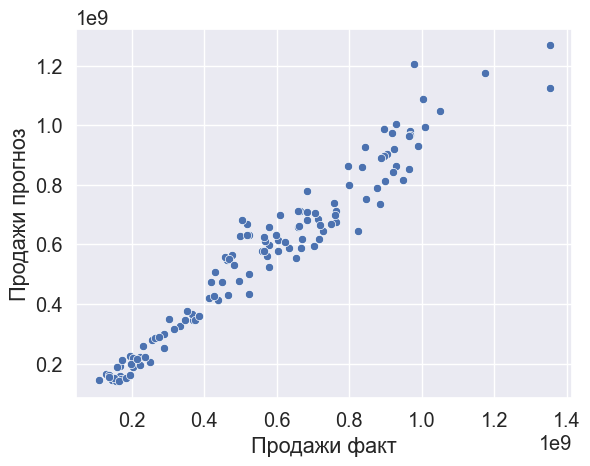

In [ ]:
import matplotlib.pylab as plt
sns.set(font_scale=1.3)

sns.scatterplot(x = df_pred[(df_pred['Период'] < '2021-10')]['Продажи'],
                y = df_pred[(df_pred['Период'] < '2021-10')]['Прогноз продаж'] )

plt.xlabel(
    'Продажи факт')
plt.ylabel(
    'Продажи прогноз')

plt.show();